<a href="https://colab.research.google.com/github/Seb207/Trading_Platform_Project/blob/main/Quant%20Models/VSN_LSTM_model/IC_Quant_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Colab Setting

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Package imports

In [8]:
!pip install "numpy<2" scipy scikit-learn
!pip install scikeras tensorflow refinitiv.data fredapi optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.1 MB/s eta 0:00:00


In [9]:
import pandas as pd
import numpy as np
import refinitiv.data as rd
from fredapi import Fred

import datetime as dt
import json
import os
import pickle

from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Data Acquisition

In [14]:
START = "2000-01-01"
END = dt.datetime.today().strftime("%Y-%m-%d")

REFINITIV_TICKERS = ["SPY", "TLT.O", "GLD", "XLE", ".DXY"]
TARGET_TICKERS = ["SPY", "TLT.O", "GLD", "XLE"]

FRED_TICKERS = {
    "T10Y2Y":     "Term_Spread",
    "BAA10Y":     "Credit_Spread",
    "T10YIE":     "Breakeven_Inflation",
    "VIXCLS":     "VIX",
    "NASDAQXAU":  "Gold_Spot",
    "DCOILWTICO": "WTI_Crude",
}

OUT_PATH = "/content/drive/MyDrive/Personal Projects/IC Quant/project/data/merged_daily.csv"
DATASET_DIR = "/content/drive/MyDrive/Personal Projects/IC Quant/project/data"

MACRO_LEVEL_DIFF = ["Term_Spread", "Credit_Spread", "Breakeven_Inflation", "VIX"]
MACRO_LOG_RETURN = ["Gold_Spot", "WTI_Crude"]


In [ ]:
def key_loader(filepath):
    try:
        with open(filepath) as f:
            app_key = json.load(f)['sessions']['platform']['rdp']['app-key']
        print("Key loaded successfully")
        return app_key
    except FileNotFoundError:
        print(f"Error: '{filepath}' not found.")
        raise
    except KeyError as e:
        print(f"Error: missing key {e}.")
        raise


In [ ]:
def check_state(state, message, session):
    print(f"State: {state}")
    print(f"Message: {message}")
    print("\n")

In [ ]:
def fetch_refinitiv_data(tickers, start_date, end_date, app_key):
    """
    Fetch target assets' OHLCV and adjusted prices from Refinitiv Data API.

    :param tickers: list of ticker symbols
    :param start_date: start date (YYYY-MM-DD)
    :param end_date: end date (YYYY-MM-DD)
    :param app_key: Refinitiv app key
    :return: DataFrame with OHLCV data
    """
    session = None
    try:
        session = rd.session.desktop.Definition(app_key=app_key).get_session()
        rd.session.set_default(session)
        session.on_state(check_state)
        session.open()

        fields = [
            "TR.PriceOpen",
            "TR.PriceHigh",
            "TR.PriceLow",
            "TR.PriceClose",
            "TR.Volume"
        ]

        frames = []
        for ticker in tickers:
            print(f"[REFINITIV] Fetching {ticker} ...")
            try:
                tdf = rd.get_history(
                    universe=[ticker],
                    fields=fields,
                    interval="1D",
                    start=start_date,
                    end=end_date
                )

                if tdf is None or tdf.empty:
                    print(f"[REFINITIV] {ticker}: EMPTY")
                    continue

                tdf.index = pd.to_datetime(tdf.index)
                try:
                    tdf.index = tdf.index.tz_localize(None)
                except (TypeError, AttributeError):
                    pass

                # Remove duplicate dates from Refinitiv (can occur at DST boundary)
                tdf = tdf[~tdf.index.duplicated(keep='last')]

                if isinstance(tdf.columns, pd.MultiIndex):
                    tdf.columns = [f"{tic}_{fld}" for tic, fld in tdf.columns]
                else:
                    tdf.columns = [f"{ticker}_{col}" for col in tdf.columns]

                print(f"[REFINITIV] {ticker}: OK | rows={len(tdf)} | {tdf.index.min().date()} -> {tdf.index.max().date()}")
                frames.append(tdf)
            except Exception as e:
                print(f"[REFINITIV] {ticker}: FAIL | {e}")

        if not frames:
            raise ValueError("No Refinitiv data was fetched successfully.")

        df = pd.concat(frames, axis=1).sort_index()
        return df
    finally:
        if session is not None:
            session.close()

In [ ]:
def fetch_fred_data(tickers_dict, start_date, end_date):
    """
    Fetch macro and alternative indicators using the fredapi library.
    Key resolution: $FRED_API_KEY -> secrets.json -> error.
    """
    api_key = os.environ.get("FRED_API_KEY")
    if not api_key:
        with open("secrets.json") as f:
            api_key = json.load(f)["fred_api_key"]

    fred = Fred(api_key=api_key)
    combined_fred_data = pd.DataFrame()

    for ticker, name in tickers_dict.items():
        print(f"[FRED] Fetching {ticker} ({name}) ...")
        try:
            series = fred.get_series(ticker, observation_start=start_date, observation_end=end_date)
            if series is None or len(series) == 0:
                print(f"[FRED] {ticker}: EMPTY")
                continue

            combined_fred_data[name] = series
            sidx = pd.to_datetime(series.index)
            print(f"[FRED] {ticker}: OK | rows={len(series)} | {sidx.min().date()} -> {sidx.max().date()}")
        except Exception as e:
            print(f"[FRED] {ticker}: FAIL | {e}")

    combined_fred_data.index = pd.to_datetime(combined_fred_data.index)
    return combined_fred_data


In [ ]:
def get_raw_dataset(start_date=START, end_date=END, filepath='refinitiv-data.config.json'):
    app_key = key_loader(filepath)
    df_market = fetch_refinitiv_data(REFINITIV_TICKERS, start_date, end_date, app_key)
    df_macro = fetch_fred_data(FRED_TICKERS, start_date, end_date)

    df_merged = df_market.join(df_macro, how="left")
    df_merged = df_merged.apply(pd.to_numeric, errors='coerce')
    df_merged = df_merged.ffill()

    close_cols = [f"{t}_Price Close" for t in TARGET_TICKERS
                  if f"{t}_Price Close" in df_merged.columns]
    df_merged = df_merged.dropna(subset=close_cols, how='any')
    df_merged = df_merged.drop([".DXY_Volume"], axis=1, errors="ignore")

    return df_merged


In [ ]:
filepath = 'refinitiv-data.config.json'
df = get_raw_dataset(filepath=filepath)
print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Key is successfully loaded
State: OpenState.Pending
Message: Session opening in progress


State: OpenState.Opened
Message: Session is opened


[REFINITIV] Fetching SPY ...
[REFINITIV] SPY: OK | rows=6656 | 2000-01-03 -> 2026-04-18
[REFINITIV] Fetching TLT.O ...
[REFINITIV] TLT.O: OK | rows=6652 | 2000-01-03 -> 2026-04-18
[REFINITIV] Fetching GLD ...
[REFINITIV] GLD: OK | rows=6656 | 2000-01-03 -> 2026-04-18
[REFINITIV] Fetching XLE ...
[REFINITIV] XLE: OK | rows=6656 | 2000-01-03 -> 2026-04-18
[REFINITIV] Fetching .DXY ...
[REFINITIV] .DXY: OK | rows=6861 | 2000-01-03 -> 2026-04-18
State: OpenState.Closed
Message: Session is closed


[FRED] Fetching T10Y2Y (Term_Spread) ...


/var/folders/tb/s30z0y490_v93zpcpl74ffn40000gn/T/ipykernel_67309/762530133.py:64:Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.


[FRED] T10Y2Y: OK | rows=6860 | 2000-01-03 -> 2026-04-17
[FRED] Fetching BAA10Y (Credit_Spread) ...
[FRED] BAA10Y: OK | rows=6859 | 2000-01-03 -> 2026-04-16
[FRED] Fetching T10YIE (Breakeven_Inflation) ...
[FRED] T10YIE: OK | rows=6077 | 2003-01-02 -> 2026-04-17
[FRED] Fetching VIXCLS (VIX) ...
[FRED] VIXCLS: OK | rows=6859 | 2000-01-03 -> 2026-04-16
[FRED] Fetching NASDAQXAU (Gold_Spot) ...
[FRED] NASDAQXAU: OK | rows=5641 | 2004-09-02 -> 2026-04-16
[FRED] Fetching DCOILWTICO (WTI_Crude) ...
[FRED] DCOILWTICO: OK | rows=6856 | 2000-01-03 -> 2026-04-13
Data shape: (5588, 30)
Date range: 2004-11-18 00:00:00 to 2026-04-18 00:00:00


In [ ]:
df

,SPY_Price Open,SPY_Price High,SPY_Price Low,SPY_Price Close,SPY_Volume,TLT.O_Price Open,TLT.O_Price High,TLT.O_Price Low,TLT.O_Price Close,TLT.O_Volume,...,.DXY_Price Open,.DXY_Price High,.DXY_Price Low,.DXY_Price Close,Term_Spread,Credit_Spread,Breakeven_Inflation,VIX,Gold_Spot,WTI_Crude
Date,,,,,,,,,,,,,,,,,,,,,
2004-11-18,118.49,118.80,118.23,118.74,31910700.0,88.550,89.06,88.410,88.97,891500.0,...,83.320,83.900,83.100,83.690,1.26,2.01,2.48,12.98,108.33,46.30
2004-11-19,118.70,118.72,117.14,117.42,54280400.0,88.900,89.03,88.090,88.26,1244500.0,...,83.870,83.910,83.010,83.310,1.25,1.99,2.53,13.50,109.69,48.90
2004-11-22,117.17,118.12,117.03,117.98,37574400.0,88.350,88.87,88.300,88.72,511500.0,...,83.270,83.390,83.080,83.190,1.23,1.96,2.56,12.97,109.69,48.48
2004-11-23,117.93,118.26,117.37,118.16,41973400.0,88.500,89.20,88.480,88.83,747600.0,...,83.170,83.540,82.810,82.970,1.21,1.96,2.54,12.67,107.71,48.74
2004-11-24,118.27,118.59,118.05,118.44,29735000.0,88.910,88.91,88.730,88.83,309700.0,...,82.900,82.960,82.360,82.410,1.19,1.95,2.56,12.72,107.21,49.14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-14,687.69,694.58,687.66,694.46,63480529.0,86.700,87.24,86.630,87.21,16606917.0,...,98.373,98.414,97.969,98.124,0.50,1.70,2.37,18.36,409.35,100.72
2026-04-15,695.26,700.28,694.20,699.94,58240384.0,87.020,87.07,86.725,86.83,15119636.0,...,98.067,98.285,98.005,98.055,0.53,1.69,2.39,18.17,399.99,100.72
2026-04-16,701.06,702.78,698.53,701.66,49972363.0,86.915,86.97,86.200,86.28,20001034.0,...,98.012,98.292,97.832,98.215,0.54,1.71,2.39,17.94,398.38,100.72


In [ ]:
df.to_csv(OUT_PATH)

# Data Preprocessing

In [15]:
df = pd.read_csv(OUT_PATH, index_col=0, parse_dates=True)

In [16]:
def transform_macro(df, level_diff_cols, log_return_cols):
    out = pd.DataFrame(index=df.index)
    for col in level_diff_cols:
        if col in df.columns:
            out[f"{col}_level"] = df[col]
            out[f"{col}_diff"] = df[col].diff()
    for col in log_return_cols:
        if col in df.columns:
            out[f"{col}_logret"] = np.log(df[col].clip(lower=1e-10) / df[col].shift(1).clip(lower=1e-10))
    if ".DXY_Price Close" in df.columns:
        dxy = pd.to_numeric(df[".DXY_Price Close"], errors="coerce")
        out["DXY_logret"] = np.log(dxy.clip(lower=1e-10) / dxy.shift(1).clip(lower=1e-10))
    return out


# Feature Engineering

In [17]:
def compute_technical_features(close):
    out = pd.DataFrame(index=close.index)
    ret_1d = np.log(close / close.shift(1))
    out["ret_1d"] = ret_1d
    out["ret_5d"] = np.log(close / close.shift(5))
    out["ret_20d"] = np.log(close / close.shift(20))

    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    out["macd"] = ema_12 - ema_26

    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1/14, adjust=False).mean()
    out["rsi_14"] = 100 - 100 / (1 + gain / loss)

    out["vol_20d"] = ret_1d.rolling(20).std() * np.sqrt(252)
    return out

def build_target_dataset(df, target, macro_features):
    close = df[f"{target}_Price Close"]
    tech = compute_technical_features(close).add_prefix(f"{target}_")
    y = np.log(close.shift(-1) / close).rename("target")
    return pd.concat([tech, macro_features, y], axis=1).dropna()

In [18]:
macro_features = transform_macro(df, MACRO_LEVEL_DIFF, MACRO_LOG_RETURN)
datasets = {t: build_target_dataset(df, t, macro_features) for t in TARGET_TICKERS}

for t, data in datasets.items():
    print(f"{t}: shape={data.shape}, range={data.index.min().date()} -> {data.index.max().date()}")

SPY: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
TLT.O: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
GLD: shape=(5567, 18), range=2004-12-16 -> 2026-04-17
XLE: shape=(5567, 18), range=2004-12-16 -> 2026-04-17


In [19]:
os.makedirs(DATASET_DIR, exist_ok=True)

for target, data in datasets.items():
    safe_name = target.replace(".", "_")
    data.to_csv(f"{DATASET_DIR}/{safe_name}_dataset.csv")
    print(f"Saved: {safe_name}_dataset.csv | shape={data.shape}")


Saved: SPY_dataset.csv | shape=(5567, 18)
Saved: TLT_O_dataset.csv | shape=(5567, 18)
Saved: GLD_dataset.csv | shape=(5567, 18)
Saved: XLE_dataset.csv | shape=(5567, 18)


In [20]:
def fit_scaler(X_train):
    return RobustScaler().fit(X_train)


# Feature Selection

In [21]:
datasets = {}
for target in TARGET_TICKERS:
    safe_name = target.replace(".", "_")
    path = f"{DATASET_DIR}/{safe_name}_dataset.csv"

    datasets[target] = pd.read_csv(path, index_col=0, parse_dates=True)
    print(f"Loaded: {safe_name}_dataset.csv | shape={datasets[target].shape}")

Loaded: SPY_dataset.csv | shape=(5567, 18)
Loaded: TLT_O_dataset.csv | shape=(5567, 18)
Loaded: GLD_dataset.csv | shape=(5567, 18)
Loaded: XLE_dataset.csv | shape=(5567, 18)


Correlation Test

In [22]:
SPEARMAN_THRESHOLD = 0.90
TOP_K = 12

def stage1_redundancy_filter(X, y, threshold=SPEARMAN_THRESHOLD):
    corr = X.corr(method='spearman').abs()
    dist = (1 - corr).clip(lower=0)
    dist_arr = dist.values.copy()
    np.fill_diagonal(dist_arr, 0)
    condensed = squareform(dist_arr, checks=False)
    Z = linkage(condensed, method='ward')
    labels = fcluster(Z, t=1 - threshold, criterion='distance')
    ic = X.corrwith(y, method='spearman').abs()
    selected = []

    for cid in np.unique(labels):
        cols = X.columns[labels == cid].tolist()
        selected.append(ic[cols].idxmax())
    return selected

XGBoost Feature Importance

In [23]:
def stage2_relevance_filter(X, y, top_k=TOP_K):
    model = XGBRegressor(max_depth=3, n_estimators=100, random_state=42, verbosity=0)
    model.fit(X, y)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    return importances.nlargest(top_k).index.tolist()

In [24]:
def select_features(X, y, top_k=TOP_K):
    stage1 = stage1_redundancy_filter(X, y)
    stage2 = stage2_relevance_filter(X[stage1], y, top_k=top_k)
    return stage2


# VSN Embedding

In [25]:
LOOKBACK = 20
VSN_HIDDEN_DIM = 32
INITIAL_TRAIN_YEARS = 5
TEST_SIZE = 60
EMBARGO = LOOKBACK


def make_sequence_dataset(data, feature_cols, lookback=LOOKBACK):
    X = data[feature_cols].values.astype(np.float32)
    y = data["target"].values.astype(np.float32)
    xs, ys = [], []
    for i in range(lookback, len(data)):
        xs.append(X[i - lookback:i])
        ys.append(y[i])
    if not xs:
        return torch.empty(0, lookback, len(feature_cols)), torch.empty(0)
    return torch.tensor(np.array(xs)), torch.tensor(np.array(ys))


In [26]:
class GatedResidualNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.gate = nn.Linear(hidden_dim, 2 * hidden_dim)
        self.skip = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        z = torch.nn.functional.elu(self.fc1(x))
        z = self.fc2(z)
        z = self.dropout(z)
        a, b = self.gate(z).chunk(2, dim=-1)
        z = a * torch.sigmoid(b)
        return self.norm(z + self.skip(x))


In [27]:
class VariableSelectionNetwork(nn.Module):
    def __init__(self, num_features, hidden_dim, dropout=0.1):
        super().__init__()
        self.feature_grns = nn.ModuleList(
            [GatedResidualNetwork(1, hidden_dim, dropout) for _ in range(num_features)]
        )
        self.selection_grn = GatedResidualNetwork(num_features, num_features, dropout)

    def forward(self, x):
        # x: [batch, time, features]
        feat = torch.stack(
            [grn(x[:, :, i:i + 1]) for i, grn in enumerate(self.feature_grns)], dim=2
        )
        weights = torch.softmax(self.selection_grn(x), dim=-1).unsqueeze(-1)
        context = (feat * weights).sum(dim=2)
        return context, weights.squeeze(-1)


In [28]:
def expanding_window_folds(n, initial_train, test_size, embargo, purge=0):
    # purge: drop the last `purge` rows of each training set to remove samples
    # whose label horizon overlaps the embargo/test region. For daily t+1 targets
    # with embargo >= 1 this is already satisfied, so default is 0.
    folds = []
    train_end = initial_train
    while train_end + embargo + test_size <= n:
        train_idx = np.arange(0, max(train_end - purge, 1))
        test_start = train_end + embargo
        test_end = test_start + test_size
        test_idx = np.arange(test_start, test_end)
        folds.append((train_idx, test_idx))
        train_end += test_size
    return folds


# LSTM Model

In [29]:
if torch.cuda.is_available():
    DEVICE = "cuda"
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
    torch.set_num_threads(4)

DEFAULT_PARAMS = {
    "lstm_hidden_dim": 32,
    "lstm_num_layers": 1,
    "lstm_dropout": 0.0,
    "vsn_dropout":   0.1,
    "lr":            1e-3,
    "batch_size":    64,
}

EPOCHS        = 25
OPTUNA_TRIALS = 8
OPTUNA_EPOCHS = 8


In [30]:
class VSNLSTMRegressor(nn.Module):
    def __init__(self, num_features, vsn_hidden_dim, lstm_hidden_dim,
                 num_layers=1, lstm_dropout=0.0, vsn_dropout=0.1):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features, vsn_hidden_dim, vsn_dropout)
        self.lstm = nn.LSTM(
            input_size=vsn_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=num_layers,
            dropout=lstm_dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.head = nn.Linear(lstm_hidden_dim, 1)

    def forward(self, x):
        context, weights = self.vsn(x)
        out, _ = self.lstm(context)
        pred = self.head(out[:, -1, :]).squeeze(-1)
        return pred, weights


In [31]:
def prepare_fold(data, train_idx, test_idx, top_k=TOP_K, lookback=LOOKBACK):
    train_df = data.iloc[train_idx]
    X_tr_raw = train_df.drop(columns=["target"])
    y_tr_raw = train_df["target"]

    feat_cols = select_features(X_tr_raw, y_tr_raw, top_k=top_k)

    scaler = fit_scaler(train_df[feat_cols])

    train_scaled = train_df.copy()
    train_scaled[feat_cols] = scaler.transform(train_df[feat_cols])

    test_start = test_idx[0]
    test_end = test_idx[-1] + 1
    test_slice = data.iloc[test_start - lookback:test_end].copy()
    test_slice[feat_cols] = scaler.transform(test_slice[feat_cols])

    X_tr, y_tr = make_sequence_dataset(train_scaled, feat_cols, lookback)
    X_te, y_te = make_sequence_dataset(test_slice, feat_cols, lookback)

    return X_tr, y_tr, X_te, y_te, feat_cols, scaler


In [32]:
def train_one_fold(X_tr, y_tr, X_te, y_te, params=None, epochs=EPOCHS):
    p = {**DEFAULT_PARAMS, **(params or {})}
    batch_size = int(p["batch_size"])

    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=batch_size, shuffle=False)

    model = VSNLSTMRegressor(
        num_features=X_tr.shape[-1],
        vsn_hidden_dim=VSN_HIDDEN_DIM,
        lstm_hidden_dim=int(p["lstm_hidden_dim"]),
        num_layers=int(p["lstm_num_layers"]),
        lstm_dropout=float(p["lstm_dropout"]),
        vsn_dropout=float(p["vsn_dropout"]),
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=float(p["lr"]))
    criterion = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred, _ = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in test_loader:
            p_out, _ = model(xb.to(DEVICE))
            preds.append(p_out.cpu())
    preds = torch.cat(preds).numpy() if preds else np.array([])
    return model, preds


In [33]:
def tune_with_optuna(data, folds, n_trials=OPTUNA_TRIALS):
    train_idx, test_idx = folds[0]
    X_tr, y_tr, X_te, y_te, _, _ = prepare_fold(data, train_idx, test_idx)

    def objective(trial):
        params = {
            "lstm_hidden_dim": trial.suggest_categorical("lstm_hidden_dim", [16, 32, 64, 128]),
            "lstm_num_layers": trial.suggest_int("lstm_num_layers", 1, 2),
            "lstm_dropout": trial.suggest_float("lstm_dropout", 0.0, 0.3),
            "vsn_dropout": trial.suggest_float("vsn_dropout", 0.0, 0.3),
            "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
            "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
        }
        _, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                  epochs=OPTUNA_EPOCHS)
        if len(preds) == 0:
            return float("inf")
        return float(((preds - y_te.numpy()) ** 2).mean())

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.tight_layout(); plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.tight_layout(); plt.show()

    return study


In [34]:
def walk_forward(data, params, folds, desc="folds"):
    all_preds, all_truth, all_dates = [], [], []
    feature_counts = {}
    fold_history = []
    last_model, last_scaler, last_feats = None, None, None

    for k, (train_idx, test_idx) in enumerate(tqdm(folds, desc=desc, leave=False)):
        X_tr, y_tr, X_te, y_te, feats, scaler = prepare_fold(data, train_idx, test_idx)
        if len(X_tr) == 0 or len(X_te) == 0:
            continue
        model, preds = train_one_fold(X_tr, y_tr, X_te, y_te, params=params,
                                      epochs=EPOCHS)
        truth = y_te.numpy()
        all_preds.append(preds)
        all_truth.append(truth)
        all_dates.append(data.index[test_idx])
        for f in feats:
            feature_counts[f] = feature_counts.get(f, 0) + 1
        last_model, last_scaler, last_feats = model, scaler, feats

        fold_mse = float(((preds - truth) ** 2).mean()) if len(preds) else float("nan")
        fold_hit = float(((preds * truth) > 0).mean()) if len(preds) else float("nan")
        fold_history.append({
            "fold": k,
            "train_end": data.index[train_idx[-1]],
            "test_start": data.index[test_idx[0]],
            "test_end": data.index[test_idx[-1]],
            "n_train": len(X_tr),
            "n_test": len(X_te),
            "mse": fold_mse,
            "hit": fold_hit,
        })

    preds = np.concatenate(all_preds) if all_preds else np.array([])
    truth = np.concatenate(all_truth) if all_truth else np.array([])
    if all_dates:
        dates = pd.DatetimeIndex(np.concatenate([d.values for d in all_dates]))[:len(preds)]
    else:
        dates = pd.DatetimeIndex([])
    preds_df = pd.DataFrame({"pred": preds, "truth": truth}, index=dates)
    fold_history_df = pd.DataFrame(fold_history)
    return preds_df, feature_counts, last_model, last_scaler, last_feats, fold_history_df

In [35]:
SAVE_DIR = "/content/drive/MyDrive/Personal Projects/IC Quant/project/model"  # Google Colab
# SAVE_DIR = "../model"


def save_target(target, result, params, save_dir=SAVE_DIR):
    safe = target.replace(".", "_")
    result["preds"].to_csv(f"{save_dir}/{safe}_preds.csv")
    result["fold_history"].to_csv(f"{save_dir}/{safe}_fold_history.csv", index=False)
    torch.save(result["last_model"].state_dict(), f"{save_dir}/{safe}_model.pt")
    with open(f"{save_dir}/{safe}_scaler.pkl", "wb") as f:
        pickle.dump(result["last_scaler"], f)
    with open(f"{save_dir}/{safe}_feats.json", "w") as f:
        json.dump(result["last_feats"], f)
    with open(f"{save_dir}/{safe}_params.json", "w") as f:
        json.dump(params, f, indent=2)
    print(f"  [{target}] saved to {save_dir}/")


def load_results(save_dir=SAVE_DIR):
    loaded = {}
    for target in TARGET_TICKERS:
        safe = target.replace(".", "_")
        preds_df = pd.read_csv(f"{save_dir}/{safe}_preds.csv", index_col=0, parse_dates=True)
        with open(f"{save_dir}/{safe}_feats.json") as f:
            feats = json.load(f)
        with open(f"{save_dir}/{safe}_scaler.pkl", "rb") as f:
            scaler = pickle.load(f)
        with open(f"{save_dir}/{safe}_params.json") as f:
            best = {**DEFAULT_PARAMS, **json.load(f)}

        model = VSNLSTMRegressor(
            num_features=len(feats),
            vsn_hidden_dim=VSN_HIDDEN_DIM,
            lstm_hidden_dim=int(best["lstm_hidden_dim"]),
            num_layers=int(best["lstm_num_layers"]),
            lstm_dropout=float(best["lstm_dropout"]),
            vsn_dropout=float(best["vsn_dropout"]),
        )
        state = torch.load(f"{save_dir}/{safe}_model.pt", map_location="cpu")
        model.load_state_dict(state)
        model.eval()

        loaded[target] = {"model": model, "scaler": scaler, "feats": feats, "preds": preds_df}
        print(f"Loaded {target}: feats={len(feats)}, preds={len(preds_df)}")

    return loaded


targets:   0%|          | 0/4 [00:00<?, ?it/s]

[SPY] n=5567, folds=71


  0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_3442/3372468864.py:24:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


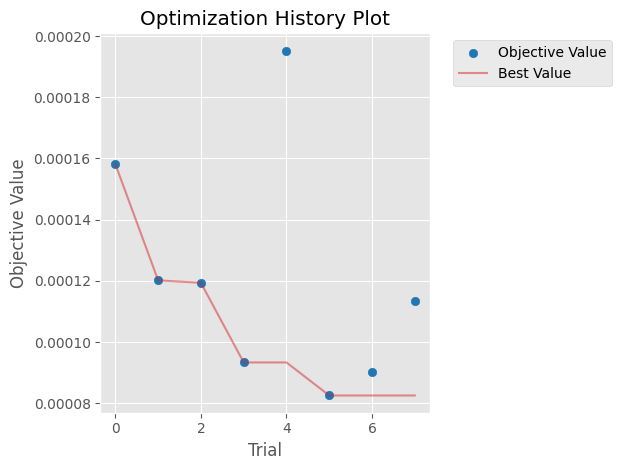

/tmp/ipykernel_3442/3372468864.py:26:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


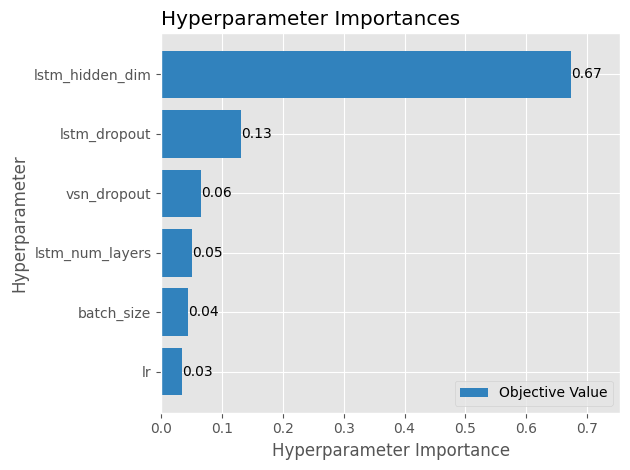

[SPY] best params: {'lstm_hidden_dim': 128, 'lstm_num_layers': 2, 'lstm_dropout': 0.09363955761336219, 'vsn_dropout': 0.24275540364675605, 'lr': 0.002666829430638381, 'batch_size': 128}


SPY folds:   0%|          | 0/71 [00:00<?, ?it/s]

  [SPY] saved to /content/drive/MyDrive/Personal Projects/IC Quant/project/model/
[SPY] walk-forward: n=4260, mse=0.000120, hit=0.485

[TLT.O] n=5567, folds=71


  0%|          | 0/8 [00:00<?, ?it/s]

/tmp/ipykernel_3442/3372468864.py:24:ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


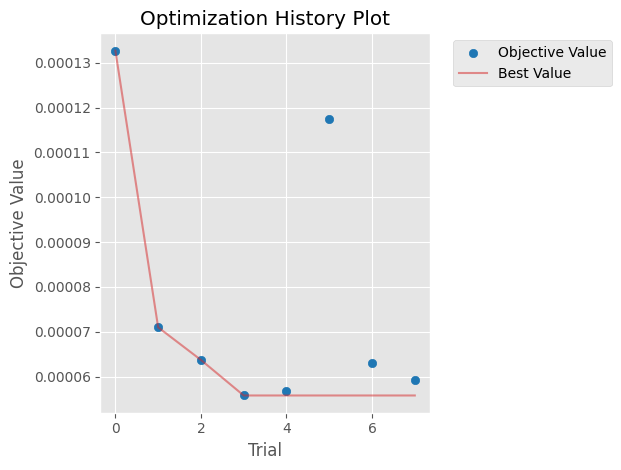

/tmp/ipykernel_3442/3372468864.py:26:ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


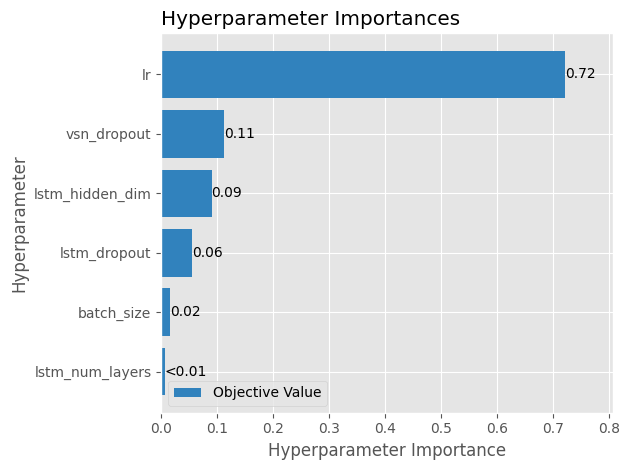

[TLT.O] best params: {'lstm_hidden_dim': 128, 'lstm_num_layers': 1, 'lstm_dropout': 0.07927886903946, 'vsn_dropout': 0.0695393711900298, 'lr': 0.00046978245288684713, 'batch_size': 32}


TLT.O folds:   0%|          | 0/71 [00:00<?, ?it/s]

In [ ]:
fold_results = {}
best_params_by_target = {}
os.makedirs(SAVE_DIR, exist_ok=True)

for target in tqdm(TARGET_TICKERS, desc="targets"):
    data = datasets[target]
    n = len(data)
    initial_train = min(int(252 * INITIAL_TRAIN_YEARS), n // 2)
    folds = expanding_window_folds(n, initial_train, TEST_SIZE, EMBARGO)
    print(f"[{target}] n={n}, folds={len(folds)}")

    study = tune_with_optuna(data, folds, n_trials=OPTUNA_TRIALS)
    best_params = study.best_params
    best_params_by_target[target] = best_params
    print(f"[{target}] best params: {best_params}")

    preds_df, feat_counts, last_model, last_scaler, last_feats, fold_hist = walk_forward(
        data, best_params, folds, desc=f"{target} folds"
    )
    mse = float(((preds_df["pred"] - preds_df["truth"]) ** 2).mean())
    hit = float(((preds_df["pred"] * preds_df["truth"]) > 0).mean())
    result = {
        "preds": preds_df,
        "feature_counts": feat_counts,
        "mse": mse,
        "hit": hit,
        "last_model": last_model,
        "last_scaler": last_scaler,
        "last_feats": last_feats,
        "fold_history": fold_hist,
    }
    fold_results[target] = result
    save_target(target, result, best_params)
    print(f"[{target}] walk-forward: n={len(preds_df)}, mse={mse:.6f}, hit={hit:.3f}\n")

summary_df = pd.DataFrame(
    {t: {"n": len(r["preds"]), "mse": r["mse"], "hit": r["hit"]}
     for t, r in fold_results.items()}
).T

with open(f"{SAVE_DIR}/best_params.json", "w") as f:
    json.dump(best_params_by_target, f, indent=2)
summary_df.to_csv(f"{SAVE_DIR}/summary.csv")
print(f"Summary saved to {SAVE_DIR}/")

summary_df


In [ ]:
def predict_next(model, scaler, feats, recent_data, lookback=LOOKBACK, device="cpu"):
    """Predict t+1 log return from the last `lookback` rows of *raw* (unscaled) data.

    recent_data: DataFrame containing all columns in `feats` (e.g. the same
                 per-target dataset used for training, without the 'target' column).
    Returns (predicted log return, per-feature VSN weights averaged over the window).
    """
    if len(recent_data) < lookback:
        raise ValueError(f"Need at least {lookback} rows, got {len(recent_data)}")
    window = recent_data[feats].iloc[-lookback:].values.astype(np.float32)
    scaled = scaler.transform(window)
    x = torch.tensor(scaled[None, :, :]).to(device)
    model.to(device).eval()
    with torch.no_grad():
        pred, weights = model(x)
    w = weights.cpu().numpy()[0]
    return float(pred.cpu().item()), dict(zip(feats, w.mean(axis=0)))

In [ ]:
# load_results() usage example:
# loaded = load_results()
# pred, weights = predict_next(
#     loaded["SPY"]["model"], loaded["SPY"]["scaler"], loaded["SPY"]["feats"],
#     recent_data=datasets["SPY"].drop(columns=["target"])
# )


# Validation


In [ ]:
def validation_metrics(preds_df):
    p = preds_df["pred"].values
    t = preds_df["truth"].values
    return {
        "n": len(p),
        "mse": float(((p - t) ** 2).mean()),
        "mae": float(np.abs(p - t).mean()),
        "rmse": float(np.sqrt(((p - t) ** 2).mean())),
        "ic_spearman": float(pd.Series(p).corr(pd.Series(t), method="spearman")),
        "ic_pearson": float(pd.Series(p).corr(pd.Series(t), method="pearson")),
        "hit_ratio": float(((p * t) > 0).mean()),
    }

In [ ]:
validation_df = pd.DataFrame(
    {t: validation_metrics(r["preds"]) for t, r in fold_results.items()}
).T
print(validation_df.round(5))

# (1) IC
validation_df[["ic_spearman", "ic_pearson"]].plot.bar(figsize=(8, 4), title="Information Coefficient per target")
plt.axhline(0, color="k", lw=0.5); plt.tight_layout(); plt.show()

# (2) Hit ratio
validation_df[["hit_ratio"]].plot.bar(figsize=(8, 4), title="Hit Ratio per target")
plt.axhline(0.5, color="k", ls="--", lw=0.5); plt.tight_layout(); plt.show()

# (3) Predicted vs Actual scatter (per target)
fig, axes = plt.subplots(1, len(TARGET_TICKERS), figsize=(4 * len(TARGET_TICKERS), 4))
axes = axes if len(TARGET_TICKERS) > 1 else [axes]
for ax, t in zip(axes, TARGET_TICKERS):
    df = fold_results[t]["preds"]
    ax.scatter(df["truth"], df["pred"], s=4, alpha=0.4)
    lim = max(df["truth"].abs().max(), df["pred"].abs().max())
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=0.5)
    ax.set_title(t); ax.set_xlabel("Truth"); ax.set_ylabel("Pred")
plt.suptitle("Predicted vs Actual"); plt.tight_layout(); plt.show()

# (4) Fold-level Hit ratio stability
fig, ax = plt.subplots(figsize=(10, 4))
for t in TARGET_TICKERS:
    fh = fold_results[t]["fold_history"].set_index("test_start")
    fh["hit"].plot(ax=ax, marker="o", ms=3, label=t)
ax.axhline(0.5, color="k", ls="--", lw=0.5)
ax.set_title("Hit ratio across folds"); plt.legend(); plt.tight_layout(); plt.show()

# (5) Feature selection frequency
combined = {}
for r in fold_results.values():
    for f, c in r["feature_counts"].items():
        combined[f] = combined.get(f, 0) + c
pd.Series(combined).sort_values().tail(15).plot.barh(
    figsize=(8, 5), title="Top-15 feature selection frequency (all targets, all folds)"
)
plt.tight_layout()
plt.show()

validation_df.round(5)

# Backtesting


In [ ]:
def backtest(preds_df, threshold=0.0):
    p = preds_df["pred"]
    t = preds_df["truth"]
    position = np.sign(p)
    if threshold > 0:
        position = position.where(p.abs() > threshold, 0)
    strat_ret = position * t
    bench_ret = t
    return pd.DataFrame({
        "position": position,
        "strat_ret": strat_ret,
        "bench_ret": bench_ret,
        "strat_eq": np.exp(strat_ret.cumsum()),
        "bench_eq": np.exp(bench_ret.cumsum()),
    }, index=preds_df.index)

In [ ]:
def perf_metrics(ret, periods=252):
    ret = ret.dropna()
    if len(ret) == 0:
        return {}
    equity = np.exp(ret.cumsum())
    ann_ret = ret.mean() * periods
    ann_vol = ret.std() * np.sqrt(periods)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0.0
    downside = ret[ret < 0].std() * np.sqrt(periods)
    sortino = ann_ret / downside if downside > 0 else 0.0
    dd = float((equity / equity.cummax() - 1).min())
    total_ret = float(equity.iloc[-1]) - 1
    years = len(ret) / periods
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0.0
    calmar = cagr / abs(dd) if dd < 0 else 0.0
    return {
        "total_return": float(total_ret),
        "cagr": float(cagr),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "sortino": float(sortino),
        "max_drawdown": dd,
        "calmar": float(calmar),
        "win_rate": float((ret > 0).mean()),
    }

In [ ]:
backtest_results = {t: backtest(r["preds"]) for t, r in fold_results.items()}

perf_rows = []
for t, bt in backtest_results.items():
    strat = perf_metrics(bt["strat_ret"])
    bench = perf_metrics(bt["bench_ret"])
    row = {"target": t}
    row.update({f"strat_{k}": v for k, v in strat.items()})
    row.update({f"bench_{k}": v for k, v in bench.items()})
    perf_rows.append(row)
perf_df = pd.DataFrame(perf_rows).set_index("target")
print(perf_df.round(4))

# Equity curves + drawdowns per target
fig, axes = plt.subplots(len(TARGET_TICKERS), 2, figsize=(14, 3 * len(TARGET_TICKERS)))
axes = axes.reshape(len(TARGET_TICKERS), 2)
for i, t in enumerate(TARGET_TICKERS):
    bt = backtest_results[t]
    bt[["strat_eq", "bench_eq"]].rename(columns={"strat_eq": "Strategy", "bench_eq": "Buy & Hold"}).plot(
        ax=axes[i, 0], logy=True, title=f"{t} — Equity (log scale)"
    )
    pd.DataFrame({
        "Strategy": bt["strat_eq"] / bt["strat_eq"].cummax() - 1,
        "Buy & Hold": bt["bench_eq"] / bt["bench_eq"].cummax() - 1,
    }).plot.area(ax=axes[i, 1], alpha=0.4, title=f"{t} — Drawdown")
plt.tight_layout(); plt.show()

# Sharpe + Max DD summary
perf_df[["strat_sharpe", "bench_sharpe"]].rename(
    columns={"strat_sharpe": "Strategy", "bench_sharpe": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Sharpe: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df[["strat_max_drawdown", "bench_max_drawdown"]].rename(
    columns={"strat_max_drawdown": "Strategy", "bench_max_drawdown": "Buy & Hold"}
).plot.bar(figsize=(9, 4), title="Max Drawdown: Strategy vs Buy & Hold")
plt.tight_layout(); plt.show()

perf_df.round(4)